In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest


In [2]:
# Load the CSV file into a DataFrame
data = pd.read_csv('../data/data_uncorr.csv')


#drop status_encoded
data = data.drop("status_encoded", axis=1)

# Display the first few rows of the DataFrame
data.head()

,Unnamed: 0,name,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,...,private_equity,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,time_to_first_funding
0,0,#waywire,News,1750000.0,acquired,USA,NY,New York City,New York,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.079452
1,11,1000 Markets,Marketplaces,500000.0,acquired,other,other,other,other,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.367123
2,12,1000memories,Curated Web,2535000.0,acquired,USA,CA,SF Bay Area,San Francisco,2.0,...,0.0,0.0,2520000.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.495890
3,17,100Plus,Analytics,1250000.0,acquired,USA,CA,SF Bay Area,San Francisco,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.128767
4,20,10BestThings,Curated Web,50000.0,closed,USA,OH,Cleveland,Cleveland,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


# One hot encoding

#### Binary Representation of Funding Rounds

In [3]:
#data['had_round_A'] = [0 if x==0 else 1 for x in data['round_A']]
#data['had_round_B'] = [0 if x==0 else 1 for x in data['round_B']]
#data['had_round_C'] = [0 if x==0 else 1 for x in data['round_C']]
#data['had_round_D'] = [0 if x==0 else 1 for x in data['round_D']]
#data['had_round_E'] = [0 if x==0 else 1 for x in data['round_E']]
#data['had_round_F'] = [0 if x==0 else 1 for x in data['round_F']]
#data['had_round_G'] = [0 if x==0 else 1 for x in data['round_G']]
#data['had_venture'] = [0 if x==0 else 1 for x in data['venture']]
#data['had_seed'] = [0 if x==0 else 1 for x in data['seed']]
#data['had_eq_crowdfunding'] = [0 if x==0 else 1 for x in data['equity_crowdfunding']]
#data['had_pd_crowdfunding'] = [0 if x==0 else 1 for x in data['product_crowdfunding']]
#data['had_angel'] = [0 if x==0 else 1 for x in data['angel']]
#data['had_grant'] = [0 if x==0 else 1 for x in data['grant']]
#data['had_pe'] = [0 if x==0 else 1 for x in data['private_equity']]
#data['had_convert'] = [0 if x==0 else 1 for x in data['convertible_note']]

In [4]:
data.columns

Index(['Unnamed: 0', 'name', 'market', 'funding_total_usd', 'status',
       'country_code', 'state_code', 'region', 'city', 'funding_rounds',
       'founded_month', 'founded_year', 'seed', 'venture',
       'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity',
       'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D',
       'round_E', 'round_F', 'round_G', 'time_to_first_funding'],
      dtype='object')

### Market Groups

In [5]:
# Define the mapping of markets to market groups
market_groups_mapping = {
    "Software & Tecnologie Digitali": [
        "Software", "Mobile", "Enterprise Software", "SaaS", "Cloud Computing",
        "Analytics", "AI & Machine Learning", "Data Security", "IT & Cybersecurity"
    ],
    "Salute, Benessere & Biotech": [
        "Health Care", "Health and Wellness", "Medical", "Pharmaceuticals",
        "Medical Devices", "Mobile Health", "Bioinformatics", "Healthcare Services"
    ],
    "E-Commerce & Retail": [
        "E-Commerce", "Online Shopping", "Mobile Commerce", "Retail",
        "Marketplaces", "Consumer Goods", "Fashion", "Mobile Advertising"
    ],
    "Media, Comunicazione & Intrattenimento": [
        "Social Media", "Social Network Media", "Social Media Marketing",
        "Entertainment", "Music", "Video Streaming", "Social Games", "Online Video Advertising"
    ],
    "Finanza & Business": [
        "Finance", "Financial Services", "Payments", "Venture Capital",
        "Crowdfunding", "Personal Finance", "Investment Management", "Business Analytics"
    ],
    "Educazione & Formazione": [
        "Education", "K-12 Education", "Career Management", "Training",
        "Language Learning", "Tutoring"
    ],
    "Tecnologie Innovative & Energia": [
        "Clean Technology", "Renewable Energies", "Solar", "Energy Efficiency",
        "Energy IT", "Smart Grid"
    ],
    "Automotive & Trasporti": [
        "Automotive", "Transportation", "Cars", "Fleet Management", "Taxis"
    ],
    "Real Estate & Immobili": [
        "Real Estate", "Property Management", "Commercial Real Estate", "Residential Solar"
    ],
    "Diversi & Altri Settori": [
        "Startups", "Consulting", "Nonprofits", "Sports", "Events",
        "Crowdsourcing", "Art", "Charity"
    ]
}

# Create a reverse mapping for easier lookup
reverse_mapping = {market: group for group, markets in market_groups_mapping.items() for market in markets}

# Add the "market groups" column to the dataframe
data["market groups"] = data["market"].map(reverse_mapping).fillna("Unknown")

In [6]:
data["market groups"].value_counts()

market groups
Unknown                                   2474
Software & Tecnologie Digitali             943
Media, Comunicazione & Intrattenimento     234
E-Commerce & Retail                        197
Salute, Benessere & Biotech                 99
Finanza & Business                          88
Diversi & Altri Settori                     79
Tecnologie Innovative & Energia             72
Educazione & Formazione                     45
Automotive & Trasporti                      23
Real Estate & Immobili                      15
Name: count, dtype: int64

In [7]:
# Perform one-hot encoding on the 'market groups' column
market_groups_encoded = pd.get_dummies(data['market groups'], prefix='market_group', drop_first=True) #DA METTERE drop_first=True? per collinearità tolgo prima colonna

# Concatenate the encoded columns back to the original dataframe
data = pd.concat([data, market_groups_encoded], axis=1)

# Convert True/False to 0/1 for all boolean columns
market_groups_encoded = market_groups_encoded.astype(int)

# Aggiorna il dataframe originale
data.update(market_groups_encoded)

/var/folders/40/3c2fxmws2gv75t7hh_svrby40000gn/T/ipykernel_16872/3020932841.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.update(market_groups_encoded)
/var/folders/40/3c2fxmws2gv75t7hh_svrby40000gn/T/ipykernel_16872/3020932841.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.update(market_groups_encoded)
/var/folders/40/3c2fxmws2gv75t7hh_svrby40000gn/T/ipykernel_16872/3020932841.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.u

In [8]:
# dropping column market and market_groups after creating dummies
data.drop(columns=['market groups'], inplace=True)
data.drop(columns=['market'], inplace=True)

In [9]:
#stamp all regions in the database
regions = data['region'].unique()
print("Regions in the database:")
for region in regions:
    print(region)

Regions in the database:
New York City
other
SF Bay Area
Cleveland
Los Angeles
Guangzhou
Seattle
Orange County, California
Rochester, New York
Denver
Boston
Orlando
Guangdong
IRL - Other
Seoul
Edinburgh
Raleigh
Austin
Wellington
London
Minneapolis
Fuzhou Shi
Shanghai
Beijing
Perm
Indianapolis
Neuilly-sur-seine
Chandigarh
Chicago
San Diego
Montreal
DEU - Other
Houston
Vienna
Charlotte
Toronto
Barcelona
Ottawa
Santa Barbara
Atlanta
Mumbai
NOR - Other
Copenhagen
Gothenburg
Paris
Hartford
Zaragoza
Tel Aviv
CA - Other
Baltimore
Munster
ME - Other
Swindon
Berlin
Newark
Anaheim
Phoenix
Madison
Salt Lake City
Hong Kong
Hamburg
Washington, D.C.
Munich
ISR - Other
Hanover
Providence
Rockford
Kansas City
Fort Myers
Santiago
Nashville
Philadelphia
Portland, Oregon
Hyderabad
Helsinki
Singapore
Dallas
Miami
Montpellier
GBR - Other
KS - Other
Newbury
IN - Other
Omaha
Zurich
Frankfurt
Eugene
New Delhi
MS - Other
Albany, New York
Manchester, New Hampshire
Lexington
New Bedford
Moscow
The Hague
FRA - Ot

In [10]:
# List of region for macro-area
usa_west = ['SF Bay Area', 'Los Angeles', 'Seattle', 'San Diego', 'Orange County, California',
            'Denver', 'Salt Lake City', 'Anaheim', 'Phoenix', 'San Luis Obispo', 'Sacramento', 'Las Vegas']
usa_east = ['New York City', 'Boston', 'Philadelphia', 'Washington, D.C.', 'Baltimore', 'Providence',
            'Newark', 'Hartford', 'New Bedford', 'Albany, New York', 'Manchester, New Hampshire']
usa_central = ['Chicago', 'Austin', 'Houston', 'Minneapolis', 'Indianapolis', 'Columbus, Ohio',
               'Kansas City', 'Dallas', 'Atlanta', 'Nashville', 'Charlotte', 'San Antonio', 'St. Louis']
canada = ['Toronto', 'Montreal', 'Ottawa', 'Vancouver', 'Calgary', 'Edmonton', 'Quebec City', 'Gatineau']
europe = ['London', 'Berlin', 'Paris', 'Barcelona', 'Madrid', 'Dublin', 'Brussels', 'Milan',
          'Amsterdam', 'Vienna', 'Copenhagen', 'Oslo', 'Zurich', 'Frankfurt', 'Stockholm',
          'Hamburg', 'Munich', 'Manchester', 'Rome', 'Lisbon', 'Warsaw', 'Lausanne', 'Helsinki',
          'Edinburgh', 'Gothenburg', 'Antwerp', 'Geneva', 'Bucharest', 'Ljubljana', 'Turin']
middle_east = ['Tel Aviv', 'Jerusalem', 'Dubai', 'Amman', 'Bahrain']
asia = ['Tokyo', 'Seoul', 'Singapore', 'Shanghai', 'Beijing', 'Shenzhen', 'Hong Kong', 'Jakarta',
        'Bangkok', 'Mumbai', 'Chennai', 'New Delhi', 'Ahmedabad', 'Kolkata', 'Manila', 'Hanoi', 'Ho Chi Minh']
latam = ['Sao Paulo', 'Buenos Aires', 'Bogota', 'Mexico City', 'Monterrey', 'Lima', 'Recife', 'Porto Alegre']
oceania = ['Sydney', 'Melbourne', 'Wellington', 'Brisbane']
africa = ['Cape Town', 'Lagos', 'Johannesburg', 'Kampala']
other = ['other']  # catch-all for unknown or rare values

def map_macro_region(region):
    if region in usa_west:
        return 'USA - West'
    elif region in usa_east:
        return 'USA - East'
    elif region in usa_central:
        return 'USA - Central'
    elif region in canada:
        return 'Canada'
    elif region in europe:
        return 'Europe'
    elif region in middle_east:
        return 'Middle East'
    elif region in asia:
        return 'Asia'
    elif region in latam:
        return 'Latin America'
    elif region in oceania:
        return 'Oceania'
    elif region in africa:
        return 'Africa'
    elif region in other:
        return 'Other'
    else:
        return 'Rest of World'

# Apply function to dataframe
data['macro_region'] = data['region'].apply(map_macro_region)


In [11]:
region_dummies = pd.get_dummies(data['macro_region'], prefix='macro_region', drop_first=True)
data = pd.concat([data, region_dummies], axis=1)

In [12]:
# drop region  after creating dummies
data.drop(columns=['region'], inplace=True)


In [13]:
#dropping Unnamed: 0, name, country_code, state_code, city
data.drop(columns=['Unnamed: 0', 'name', 'country_code', 'state_code', 'city'], inplace=True)

In [14]:
data.columns

Index(['funding_total_usd', 'status', 'funding_rounds', 'founded_month',
       'founded_year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G',
       'time_to_first_funding', 'market_group_Diversi & Altri Settori',
       'market_group_E-Commerce & Retail',
       'market_group_Educazione & Formazione',
       'market_group_Finanza & Business',
       'market_group_Media, Comunicazione & Intrattenimento',
       'market_group_Real Estate & Immobili',
       'market_group_Salute, Benessere & Biotech',
       'market_group_Software & Tecnologie Digitali',
       'market_group_Tecnologie Innovative & Energia', 'market_group_Unknown',
       'macro_region', 'macro_region_Asia', 'macro_region_Canada',
       'macro_region_Europe', 'macro_region_Latin America',
       'macro_region_Middle 

In [15]:
# Define numerical columns
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Initialize the Isolation Forest model
iso_forest = IsolationForest(random_state=42, contamination=0.05)

# Fit the model and predict anomalies
isolation_forest_pred = iso_forest.fit_predict(data[numerical_columns])

# Outliers are marked as -1
outliers_isolation_forest = data[numerical_columns][isolation_forest_pred == -1]

# Calculate the percentage of outliers
outlier_percentage = (len(outliers_isolation_forest) / len(data)) * 100
print(f"Percentage of outliers: {outlier_percentage:.2f}%")

Percentage of outliers: 5.01%


In [16]:
# Filter out the outliers
data_no_outliers = data[isolation_forest_pred != -1]

# Display the shape of the new dataset
print(f"Shape of dataset after removing outliers: {data_no_outliers.shape}")

Shape of dataset after removing outliers: (4055, 45)


## Decide which scaler use

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Create a copy before transforming, so the original data remains unchanged
data_no_outliers_standardized = data_no_outliers.copy()

# Standardize the numerical columns on the copied dataframe
data_no_outliers_standardized[numerical_columns] = scaler.fit_transform(data_no_outliers_standardized[numerical_columns])

# Display the first few rows of the standardized data
data_no_outliers_standardized.head()

,funding_total_usd,status,funding_rounds,founded_month,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,...,macro_region_Canada,macro_region_Europe,macro_region_Latin America,macro_region_Middle East,macro_region_Oceania,macro_region_Other,macro_region_Rest of World,macro_region_USA - Central,macro_region_USA - East,macro_region_USA - West
0,-0.402849,acquired,-0.655859,0.666623,1.440145,2.150978,-0.552879,-0.020808,-0.045744,-0.051238,...,False,False,False,False,False,False,False,False,True,False
1,-0.491189,acquired,-0.655859,-0.760597,0.540517,0.424496,-0.552879,-0.020808,-0.045744,-0.051238,...,False,False,False,False,False,True,False,False,False,False
2,-0.347372,acquired,0.246893,0.952067,0.840393,-0.245378,-0.337525,-0.020808,-0.045744,-0.051238,...,False,False,False,False,False,False,False,False,False,True
3,-0.438185,acquired,0.246893,1.522955,1.140269,0.769793,-0.510150,-0.020808,-0.045744,-0.051238,...,False,False,False,False,False,False,False,False,False,True
4,-0.522991,closed,-0.655859,0.095735,0.540517,-0.197037,-0.552879,-0.020808,-0.045744,-0.051238,...,False,False,False,False,False,False,True,False,False,False


In [18]:
# Uncomment to Standardize between 0 and 1, but comment the StandardScaler cell

# from sklearn.preprocessing import MinMaxScaler

# # Initialize the MinMaxScaler
# min_max_scaler = MinMaxScaler()

# # Apply MinMaxScaler to the numerical columns
# data_no_outliers[numerical_columns] = min_max_scaler.fit_transform(data_no_outliers[numerical_columns])

# # Display the first few rows of the standardized data
# data_no_outliers.head()

## Normalize

In [19]:
#from sklearn.preprocessing import normalize

# Normalize the numerical columns
#data_no_outliers[numerical_columns] = normalize(data_no_outliers[numerical_columns])

# Display the first few rows of the normalized data
#data_no_outliers.head()

# Normalize the numerical columns
#data_no_outliers_standardized[numerical_columns] = normalize(data_no_outliers_standardized[numerical_columns])

# Display the first few rows of the normalized data
#data_no_outliers_standardized.head()

## Logistic Regression

In [25]:
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
#%pip install matplotlib
#%pip install seaborn
#%pip install statsmodels
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sklearn.linear_model as skl_lm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
''' 
Function to print relevant scoring metrics
'''

def print_scores(y_train, y_hat_train, y_test, y_hat_test, binary=True):
    if binary:
        print('Training Recall: ', 
              recall_score(y_train, y_hat_train))
        print('Testing Recall: ', 
              recall_score(y_test, y_hat_test))
        print('\n')
        print('Training F1: ', 
              f1_score(y_train, y_hat_train))
        print('Testing F1: ', 
              f1_score(y_test, y_hat_test))
        print('\n')
        false_positive_rate, true_positive_rate, thresholds = \
        roc_curve(y_test, y_hat_test)
        roc_auc = auc(false_positive_rate, true_positive_rate)
        print('ROC AUC: ', roc_auc)
        print('PR AUC: ', average_precision_score(y_test, y_hat_test))
        print('\n')
        
    else:
        print('Training Recall (weighted avg): ', 
              recall_score(y_train, y_hat_train, average='weighted'))
        print('Testing Recall (weighted avg): ', 
              recall_score(y_test, y_hat_test, average='weighted'))
        print('\n')
        print('Training Recall (macro avg): ', 
              recall_score(y_train, y_hat_train, average='macro'))
        print('Testing Recall (macro avg): ', 
              recall_score(y_test, y_hat_test, average='macro'))
        print('\n')
        print('Training F1-Score (weighted avg): ', 
              f1_score(y_train, y_hat_train, average='weighted'))
        print('Testing F1-Score (weighted avg): ', 
              f1_score(y_test, y_hat_test, average='weighted'))
        print('\n')
        print('Training F1-Score (macro avg): ', 
              f1_score(y_train, y_hat_train, average='macro'))
        print('Testing F1-Score (macro avg): ', 
              f1_score(y_test, y_hat_test, average='macro'))
        print('\n')
        print('Testing Recall (failure class): ', 
              recall_score(y_test, y_hat_test, average=None, labels=[1]))
        print('\n')
    
    print('Training Accuracy: ', accuracy_score(y_train, y_hat_train))
    print('Testing Accuracy: ', accuracy_score(y_test, y_hat_test))

In [21]:
X = data_no_outliers[numerical_columns]
y = data_no_outliers['status']

# convert status into 1 e 0
y_numeric = y.map({'acquired': 1, 'closed': 0})

# Drop rows with NaN values in y_numeric
#valid_indices = y_numeric.dropna().index
#X = X.loc[valid_indices]
#y_numeric = y_numeric.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric)

# Remove columns with constant values
X_train = X_train.loc[:, (X_train != X_train.iloc[0]).any()]

# Add a constant to the features
X_train_w_intercept = sm.add_constant(X_train)

est = sm.Logit(y_train.to_numpy(), X_train_w_intercept).fit()
est.summary().tables[1]




         Current function value: 0.583939
         Iterations: 35


/Users/valentinabonato/Desktop/develhope/projects/startup-prediction/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,coef,std err,z,P>|z|,[0.025,0.975]
const,2.8973,36.245,0.080,0.936,-68.142,73.937
funding_total_usd,3.749e-09,2.72e-08,0.138,0.890,-4.95e-08,5.7e-08
funding_rounds,0.4275,0.053,8.082,0.000,0.324,0.531
founded_month,-0.0033,0.012,-0.282,0.778,-0.026,0.020
founded_year,-0.0019,0.018,-0.103,0.918,-0.037,0.033
seed,4.19e-07,8.52e-08,4.920,0.000,2.52e-07,5.86e-07
venture,2.936e-08,2.89e-08,1.016,0.310,-2.73e-08,8.6e-08
equity_crowdfunding,0.0005,51.245,1.06e-05,1.000,-100.437,100.438
undisclosed,2.188e-06,1.9e-06,1.154,0.248,-1.53e-06,5.9e-06
convertible_note,6.504e-07,6.67e-07,0.975,0.330,-6.58e-07,1.96e-06


In [26]:
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)

/Users/valentinabonato/Desktop/develhope/projects/startup-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
y_hat_train = baseline_model.predict(X_train_scaled)
y_hat_test = baseline_model.predict(X_test_scaled)

print_scores(y_train, y_hat_train, y_test, y_hat_test)

In [22]:
print(X_train.shape)
print(y_numeric.shape)
# trova unique value per y_numeric
print(y.unique())

(3244, 31)
(4055,)
['acquired' 'closed']


##### STEPWISE BACKWARD SELECTION

In [ ]:
# Sequential Forward Selection with a more appropriate metric
sfs = SequentialFeatureSelector(
pipeline,
_features_to_select=10,
scoring f, or 'accuracy", "recall', 'precision", "roc auc"
scoring='f1', # Or cv=5
sfs. fit(X_train, y_train)
# Selected features
selected_features = [i for i, selected in enumerate(sfs get_support()) if selected]
feature_names_backward = X.columns[selected_features] if hasattr(X, 'columns') else selected_features
print(f"Selected features (Forward Selection): {selected_features)")
print (f"Feature names: (feature_names_backward}")
[80]
...
# Transform data
X_train_selected_backward = sfs.transform(X_train)
X_test_selected_backward = sfs. transform(X_test)

In [ ]:
X_test_selected_backward = pd.DataFrame(X_test_selected_backward, columns=feature_names_backward)
# Fit the pipeline on the
selected features
pipeline. fit(X_train_selected_backward, _train)
y_pred = pipeline.predict(X_test_selected_backward)
# Print a complete report
print(f"Accuracy: {pipeline.score(X_test_selected_backward, y_test):.4f}")
print ("\Confusion Matrix:")
print (confusion matrixy_test, y_pred))
[81]
print ("\Classification Report:")
print(classification reporty_test, y_pred))

In [23]:
# Add an intercept to the test dataset
X_test_w_intercept = sm.add_constant(X_test)

# Predict probabilities using the trained model
pred = est.predict(X_test_w_intercept).round(2)

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (pred > 0.5).astype(int)


ValueError: shapes (811,33) and (32,) not aligned: 33 (dim 1) != 32 (dim 0)

In [ ]:
# Print only the first 20 pairs with formatted alignment
print(f"{'Pred Prob':<12} {'Pred Class':<12}")  # Header
print("-" * 25)

for i in range(270, 290):
    print(f"{pred.values[i]:<12} {y_pred.values[i]:<12}")
    

In [ ]:
print(y_pred.value_counts())

In [ ]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [103]:
#Function to evaluate the performance of a classification model
def evaluate_classification_performance(y_test, y_pred):
    """
    Evaluate and print out standard classification metrics.
    """
    # Compute the confusion matrix
    conf_matrix = metrics.confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()

#Calculate specificity = TN / (TN + FP)
    specificity = tn / (tn + fp)

#Calculate other metrics using scikit-learn
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

#FPR = 1 - specificity
    fpr = 1 - specificity

#Print all metrics in a neat format
    print(f"Accuracy:    {accuracy:.2f}")
    print(f"Precision:   {precision:.2f}")
    print(f"Recall:      {recall:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"FPR:         {fpr:.2f}")
    print(f"F1 Score:    {f1:.2f}")

#Optionally return metrics in a dictionary if needed
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'f1_score': f1
    }


In [104]:
metrics_dict = evaluate_classification_performance(y_test, y_pred)

Accuracy:    0.58
Precision:   0.61
Recall:      0.67
Specificity: 0.48
FPR:         0.52
F1 Score:    0.63


In [105]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.48      0.51       370
           1       0.61      0.67      0.63       441

    accuracy                           0.58       811
   macro avg       0.58      0.58      0.57       811
weighted avg       0.58      0.58      0.58       811



In [106]:
# Convert y_train to numeric values (e.g., 0 and 1)
#y_train_numeric = y_train.map({'operating': 1, 'acquired': 0})

# Drop any rows with NaN values in y_train_numeric
#valid_indices = y_train_numeric.dropna().index
#y_train_numeric = y_train_numeric.loc[valid_indices]
#X_train_valid = X_train.loc[valid_indices]

# Add a constant to the features
#X_train_w_intercept = sm.add_constant(X_train_valid)

# Remove columns with constant values
#X_train_w_intercept = X_train_w_intercept.loc[:, (X_train_w_intercept != X_train_w_intercept.iloc[0]).any()]

# Fit the logistic regression model
#est = sm.Logit(y_train_numeric.to_numpy(), X_train_w_intercept).fit()
#est.summary().tables[1]

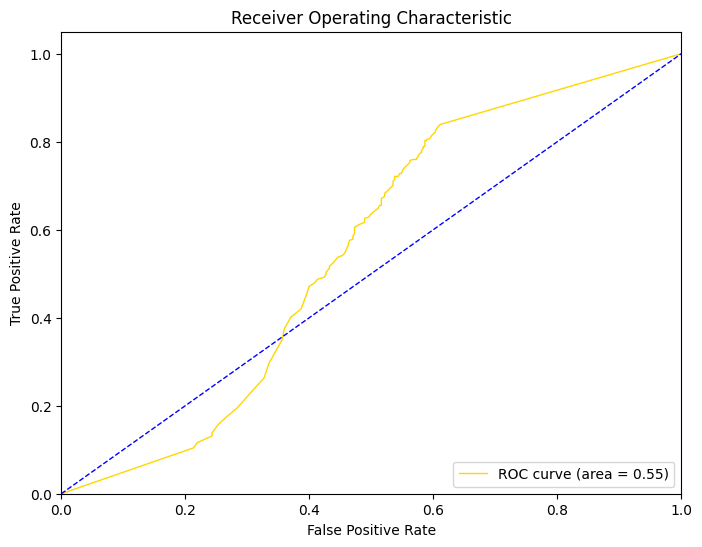

In [107]:
#Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, pred)

#Calculate AUC
roc_auc = roc_auc_score(y_test, pred)

#Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='gold', lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

In [108]:
#Calculate the Gini coefficient
gini = 2 * roc_auc - 1
print('Gini coefficient: %.2f' % gini)

Gini coefficient: 0.11


## Random Forest

In [215]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- round_G


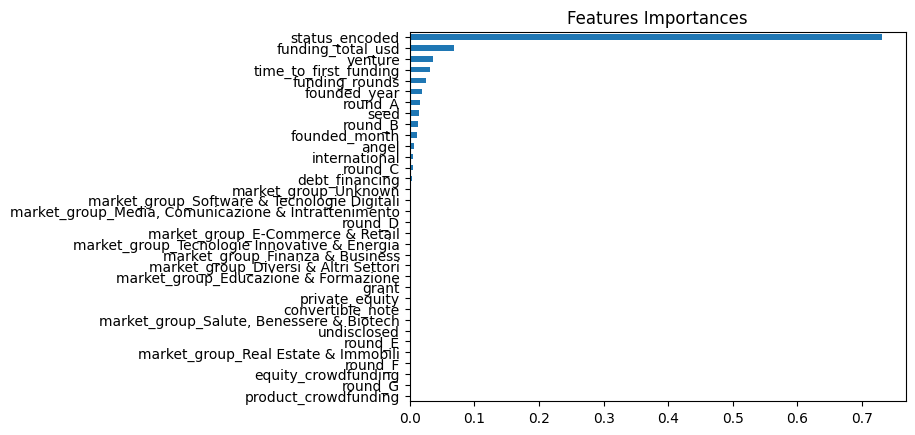

In [164]:
# Create a pd.Series of features importances
importances = pd.Series(data=rf_model.feature_importances_,
                        index= X_train.columns)
# Sort importances
importances_sorted = importances.sort_values()
# Draw a horizontal barplot of importances_sorted
importances_sorted.plot(kind='barh')
plt.title('Features Importances')
plt.show()

## Alberi decisionali

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_valid, y_train_numeric)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Align y_pred_dt with the reset indices of y_test_mapped
y_pred_dt_valid = y_pred_dt[:len(y_test_mapped)]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_mapped, y_pred_dt_valid))
print("\nClassification Report:\n", classification_report(y_test_mapped, y_pred_dt_valid))

Accuracy: 0.8798163633382522

Classification Report:
               precision    recall  f1-score   support

         0.0       0.06      0.05      0.06       404
         1.0       0.93      0.94      0.94      5695

    accuracy                           0.88      6099
   macro avg       0.50      0.50      0.50      6099
weighted avg       0.88      0.88      0.88      6099



## Modello nearest neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_valid, y_train_numeric)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Align y_pred_knn with the reset indices of y_test_mapped
y_pred_knn_valid = y_pred_knn[:len(y_test_mapped)]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_mapped, y_pred_knn_valid))
print("\nClassification Report:\n", classification_report(y_test_mapped, y_pred_knn_valid))

Accuracy: 0.9263813739957371

Classification Report:
               precision    recall  f1-score   support

         0.0       0.04      0.00      0.01       404
         1.0       0.93      0.99      0.96      5695

    accuracy                           0.93      6099
   macro avg       0.49      0.50      0.49      6099
weighted avg       0.87      0.93      0.90      6099

